In [1]:
#import libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [24]:
#load datasets
df = pd.read_csv("C:\\Users\\gagan\\Downloads\\exchange_rate.csv")

df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df.set_index("date", inplace=True)

print(df.head())
print(df.info())



            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB
None


In [12]:
#check missing vlaues
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Ex_rate    0
dtype: int64


In [13]:
#handle misssing values
df["Ex_rate"] = df["Ex_rate"].fillna(method="ffill")

print(df.isnull().sum())

Ex_rate    0
dtype: int64


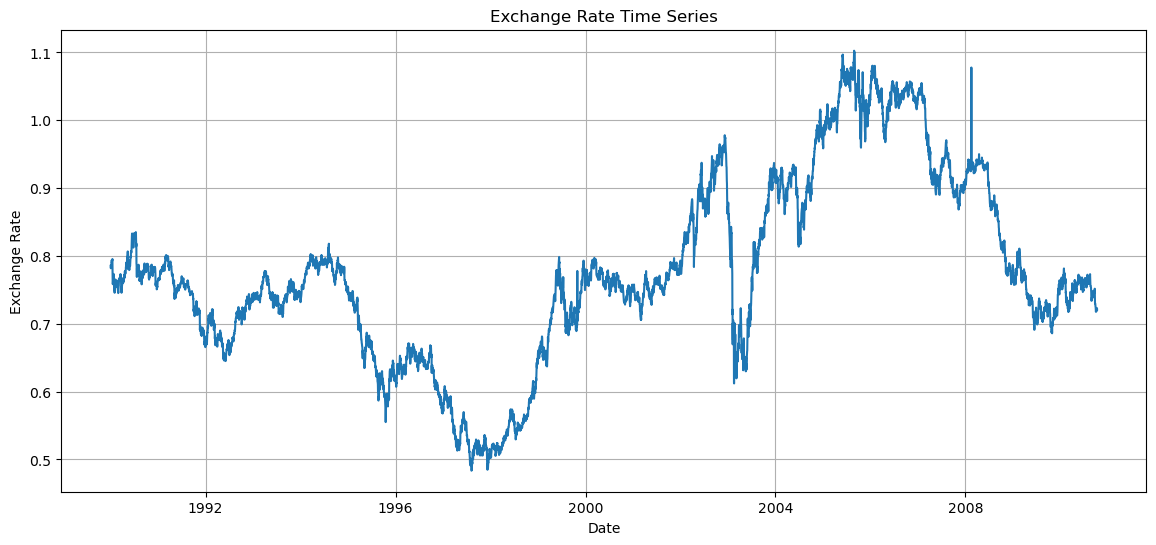

In [25]:
#tiem series plot
plt.figure(figsize=(14,6))
plt.plot(df["Ex_rate"])
plt.title("Exchange Rate Time Series")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid(True)
plt.show()

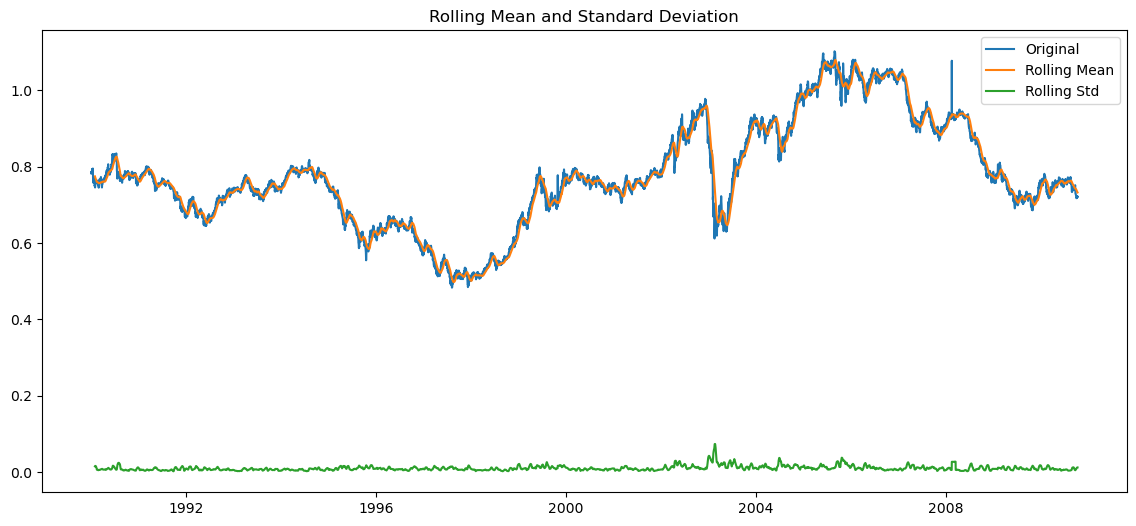

In [15]:
#rolling statistics
rolling_mean = df["Ex_rate"].rolling(window=30).mean()
rolling_std = df["Ex_rate"].rolling(window=30).std()

plt.figure(figsize=(14,6))
plt.plot(df["Ex_rate"], label="Original")
plt.plot(rolling_mean, label="Rolling Mean")
plt.plot(rolling_std, label="Rolling Std")
plt.legend()
plt.title("Rolling Mean and Standard Deviation")
plt.show()

In [16]:
#adf test
result = adfuller(df["Ex_rate"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

ADF Statistic: -1.6649941807381368
p-value: 0.4492327353597985
Series is Non-Stationary


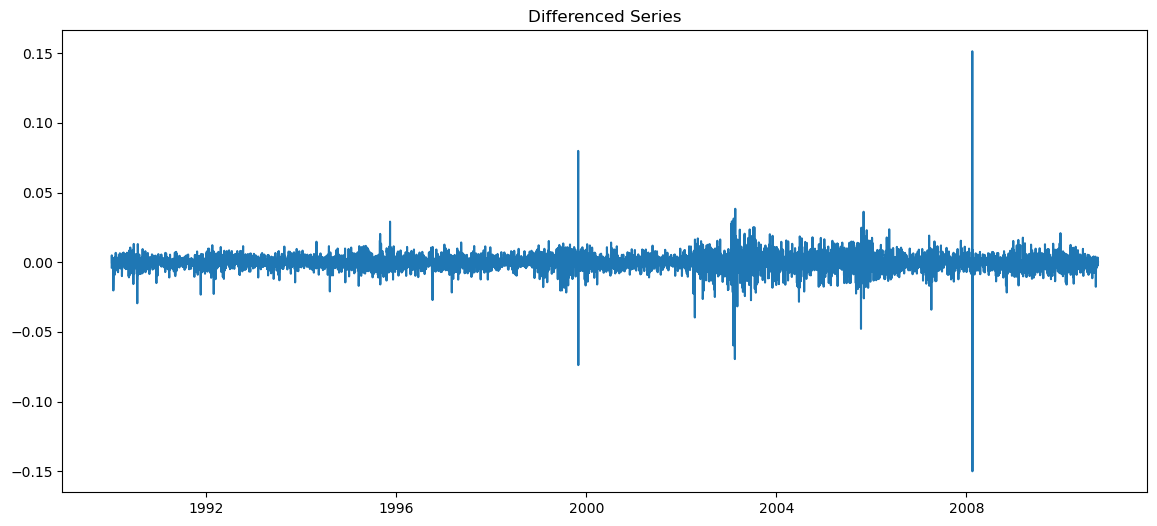

In [17]:
#differencing
diff_series = df["Ex_rate"].diff().dropna()

plt.figure(figsize=(14,6))
plt.plot(diff_series)
plt.title("Differenced Series")
plt.show()

In [18]:
#adf test after differencing
result = adfuller(diff_series)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -99.39343120118627
p-value: 0.0


<Figure size 1200x500 with 0 Axes>

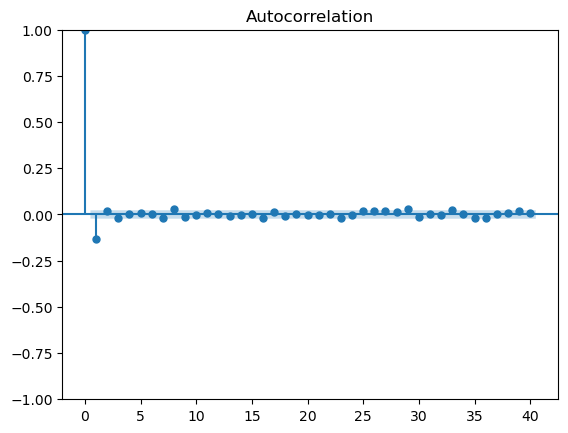

In [19]:
#acf plot
plt.figure(figsize=(12,5))
plot_acf(diff_series, lags=40)
plt.show()

<Figure size 1200x500 with 0 Axes>

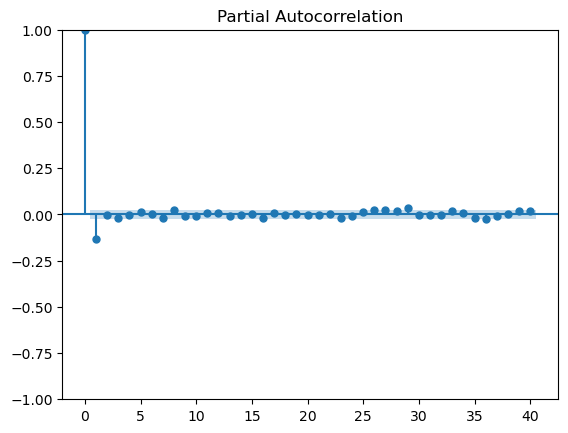

In [20]:
#pacf plot
plt.figure(figsize=(12,5))
plot_pacf(diff_series, lags=40)
plt.show()

In [21]:
#train test split
train_size = int(len(df) * 0.8)

train = df["Ex_rate"][:train_size]
test = df["Ex_rate"][train_size:]

print("Train Size:", len(train))
print("Test Size:", len(test))

Train Size: 6070
Test Size: 1518


In [22]:
#arima model
arima_model = ARIMA(train, order=(1,1,1))

arima_fit = arima_model.fit()

print(arima_fit.summary())

C:\Users\gagan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\gagan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\gagan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Fri, 05 Jun 2026   AIC                         -45432.092
Time:                        07:16:34   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

In [26]:
from statsmodels.tsa.arima.model import ARIMA

# Set daily frequency explicitly
train = train.asfreq('D')

# ARIMA Model
arima_model = ARIMA(train, order=(1,1,1))

arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Fri, 05 Jun 2026   AIC                         -45432.092
Time:                        07:20:31   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

In [29]:
#arima forecast
arima_forecast = arima_fit.forecast(steps=len(test))

arima_forecast = pd.Series(
    arima_forecast,
    index=test.index
)

print(arima_forecast.head())

date
2006-08-15    1.023685
2006-08-16    1.023606
2006-08-17    1.023653
2006-08-18    1.023625
2006-08-19    1.023642
Name: predicted_mean, dtype: float64


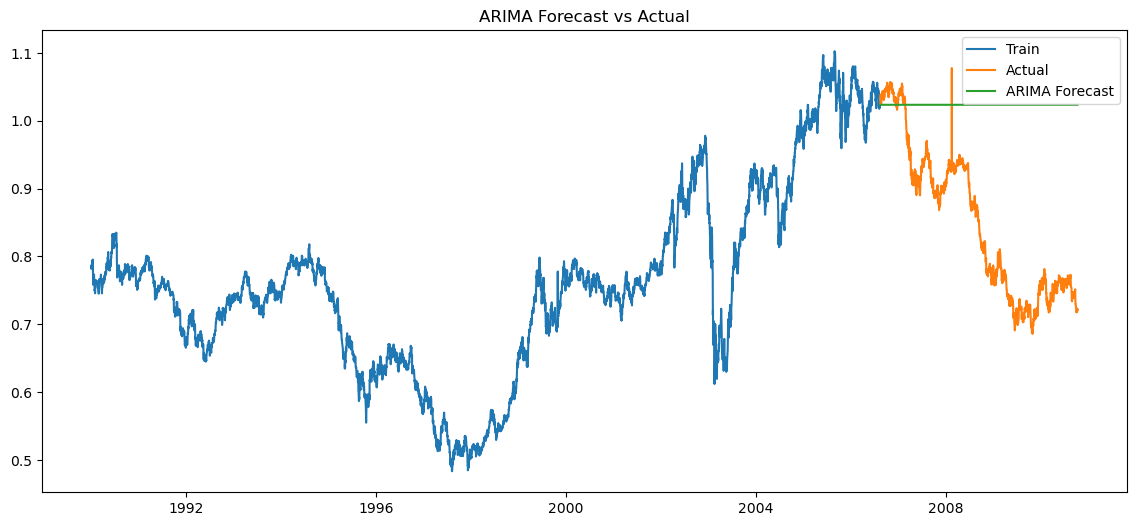

In [30]:
#arima forecast plot
plt.figure(figsize=(14,6))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(arima_forecast.index,
         arima_forecast,
         label="ARIMA Forecast")

plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

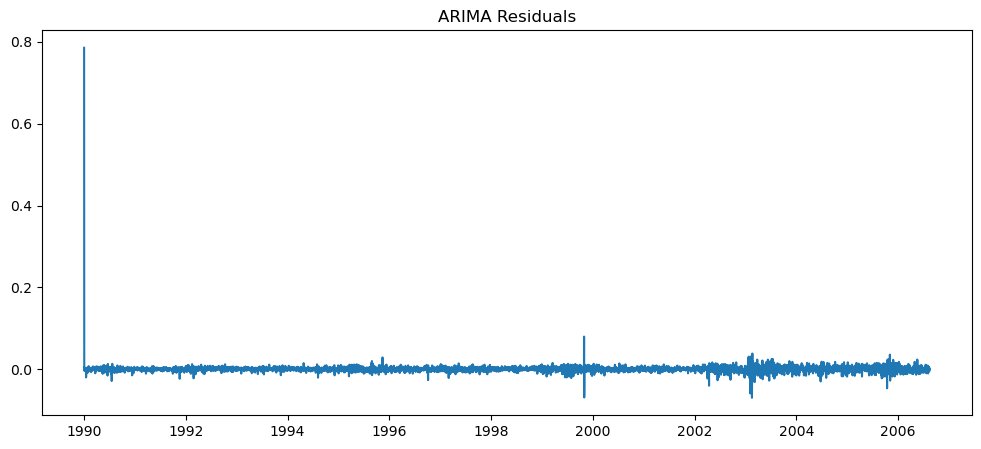

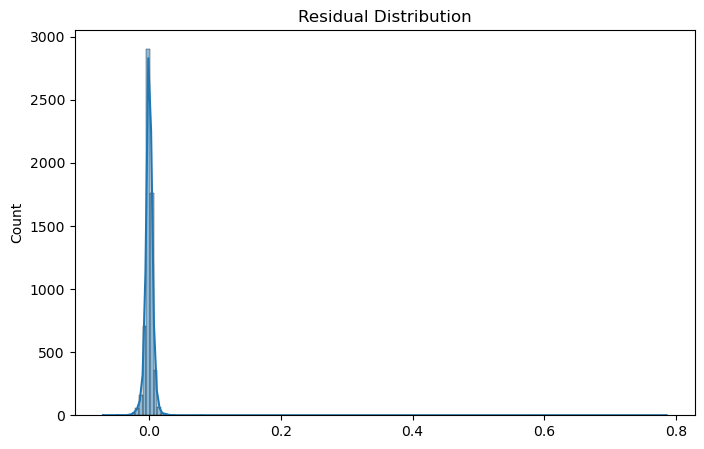

In [32]:
#arima residual diagnostics
residuals = arima_fit.resid

plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

In [33]:
#exponential smoothing model
exp_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal=None
)

exp_fit = exp_model.fit()

In [34]:
#exponential smoothing forecast
exp_forecast = exp_fit.forecast(len(test))

exp_forecast = pd.Series(
    exp_forecast,
    index=test.index
)

print(exp_forecast.head())

date
2006-08-15    1.023582
2006-08-16    1.023621
2006-08-17    1.023661
2006-08-18    1.023700
2006-08-19    1.023739
dtype: float64


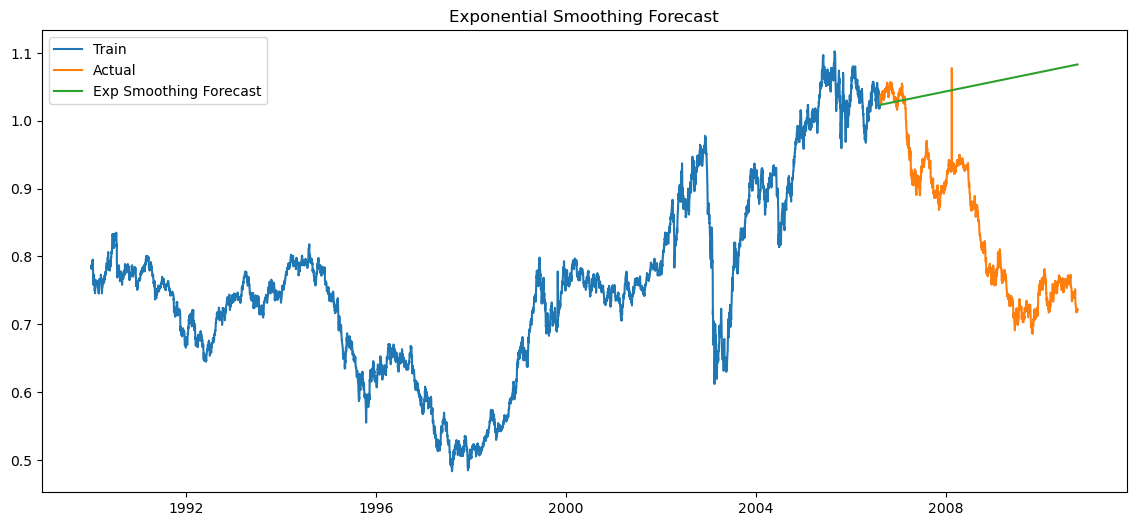

In [35]:
#exponential smoothing plot
plt.figure(figsize=(14,6))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(exp_forecast.index,
         exp_forecast,
         label="Exp Smoothing Forecast")

plt.legend()
plt.title("Exponential Smoothing Forecast")
plt.show()

In [36]:
#evaluation function
def calculate_metrics(actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mape = np.mean(
        np.abs((actual - predicted) / actual)
    ) * 100

    return mae, rmse, mape

In [37]:
#arima metrics
arima_mae, arima_rmse, arima_mape = calculate_metrics(
    test,
    arima_forecast
)

print("ARIMA Results")
print("MAE :", arima_mae)
print("RMSE:", arima_rmse)
print("MAPE:", arima_mape)

ARIMA Results
MAE : 0.17770970449120707
RMSE: 0.20543669659668565
MAPE: 22.79796617381075


In [38]:
#exponential smoothing metrics
exp_mae, exp_rmse, exp_mape = calculate_metrics(
    test,
    exp_forecast
)

print("Exponential Smoothing Results")
print("MAE :", exp_mae)
print("RMSE:", exp_rmse)
print("MAPE:", exp_mape)

Exponential Smoothing Results
MAE : 0.20659619193534684
RMSE: 0.23910443254356908
MAPE: 26.50866390075941


In [39]:
#model comparison table
comparison = pd.DataFrame({
    "Model":["ARIMA","Exponential Smoothing"],
    "MAE":[arima_mae, exp_mae],
    "RMSE":[arima_rmse, exp_rmse],
    "MAPE":[arima_mape, exp_mape]
})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,0.177710,0.205437,22.797966
1,Exponential Smoothing,0.206596,0.239104,26.508664


In [40]:
#best model
best_model = comparison.loc[
    comparison["RMSE"].idxmin()
]

print("Best Model Based on RMSE:")
print(best_model)

Best Model Based on RMSE:
Model        ARIMA
MAE        0.17771
RMSE      0.205437
MAPE     22.797966
Name: 0, dtype: object


In [41]:
print("""
Conclusion

1. Historical exchange rates were analyzed.
2. Data preprocessing was completed successfully.
3. ACF and PACF plots were used for ARIMA parameter selection.
4. ARIMA and Exponential Smoothing models were built.
5. Residual diagnostics were performed.
6. Forecasts were generated and visualized.
7. MAE, RMSE and MAPE were calculated.
8. The model with the lowest RMSE is considered the best forecasting model.
""")


Conclusion

1. Historical exchange rates were analyzed.
2. Data preprocessing was completed successfully.
3. ACF and PACF plots were used for ARIMA parameter selection.
4. ARIMA and Exponential Smoothing models were built.
5. Residual diagnostics were performed.
6. Forecasts were generated and visualized.
7. MAE, RMSE and MAPE were calculated.
8. The model with the lowest RMSE is considered the best forecasting model.



In [42]:
exp_mae, exp_rmse, exp_mape = calculate_metrics(
    test,
    exp_forecast
)

print("Exponential Smoothing Results")
print("MAE :", exp_mae)
print("RMSE:", exp_rmse)
print("MAPE:", exp_mape)

Exponential Smoothing Results
MAE : 0.20659619193534684
RMSE: 0.23910443254356908
MAPE: 26.50866390075941


In [43]:
comparison = pd.DataFrame({
    "Model":["ARIMA","Exponential Smoothing"],
    "MAE":[arima_mae, exp_mae],
    "RMSE":[arima_rmse, exp_rmse],
    "MAPE":[arima_mape, exp_mape]
})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,0.177710,0.205437,22.797966
1,Exponential Smoothing,0.206596,0.239104,26.508664


In [44]:
best_model = comparison.loc[
    comparison["RMSE"].idxmin()
]

print("Best Model:")
print(best_model)

Best Model:
Model        ARIMA
MAE        0.17771
RMSE      0.205437
MAPE     22.797966
Name: 0, dtype: object
